In [2]:
# 1. LOAD DATASET

from google.colab import files

uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())

Saving complete_renewable_energy_dataset.csv to complete_renewable_energy_dataset.csv
     Country  Year Energy Type  Production (GWh)  Installed Capacity (MW)  \
0        USA  2011       Solar      85404.690027              5549.794323   
1  Australia  2008  Geothermal      22205.069382             43211.593798   
2     Canada  2013     Biomass      94102.732038              6139.117212   
3      Japan  2010     Biomass      88771.932910             40323.639260   
4      China  2018       Solar      93288.408581             30755.403056   

   Investments (USD)  Population           GDP  Energy Consumption  \
0       5.604125e+09  1064007213  1.775278e+14       369654.644184   
1       6.361886e+08  1033255852  6.435372e+13       771781.636293   
2       6.158680e+09    14895124  1.567926e+14       342707.152899   
3       8.526116e+09  1448827283  1.350464e+14       498839.574253   
4       5.086237e+09  1499494307  8.677956e+13       819064.362785   

   Energy Exports  ...  Econom

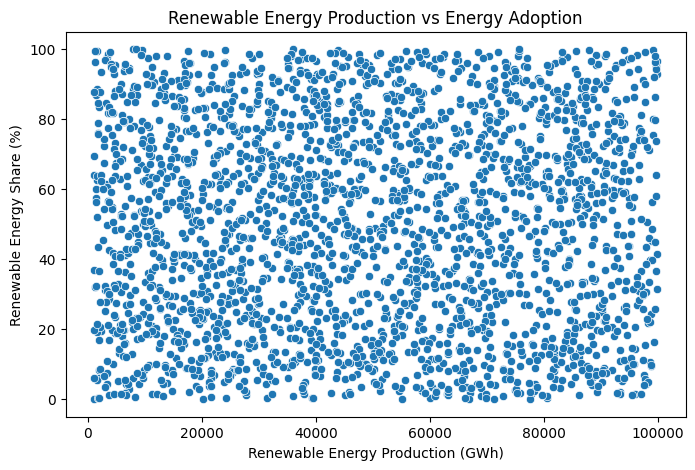

In [3]:
# 2. RENEWABLE ENERGY PRODUCTION VS ADOPTION

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Production (GWh)",
    y="Proportion of Energy from Renewables"
)

plt.title("Renewable Energy Production vs Energy Adoption")
plt.xlabel("Renewable Energy Production (GWh)")
plt.ylabel("Renewable Energy Share (%)")

plt.show()

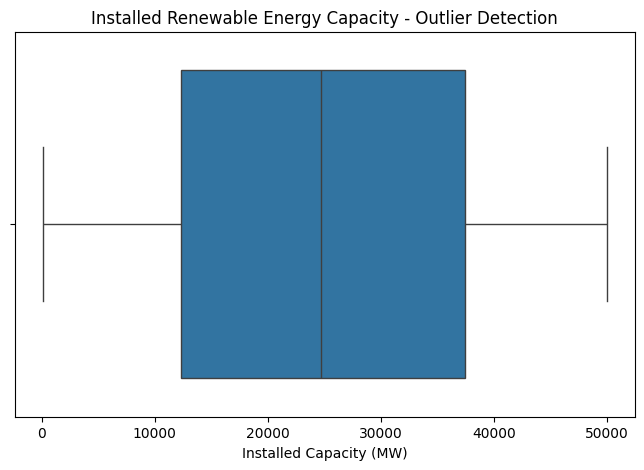

In [4]:
# 3. INSTALLED CAPACITY OUTLIER DETECTION

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Installed Capacity (MW)"]
)

plt.title("Installed Renewable Energy Capacity - Outlier Detection")
plt.xlabel("Installed Capacity (MW)")

plt.show()

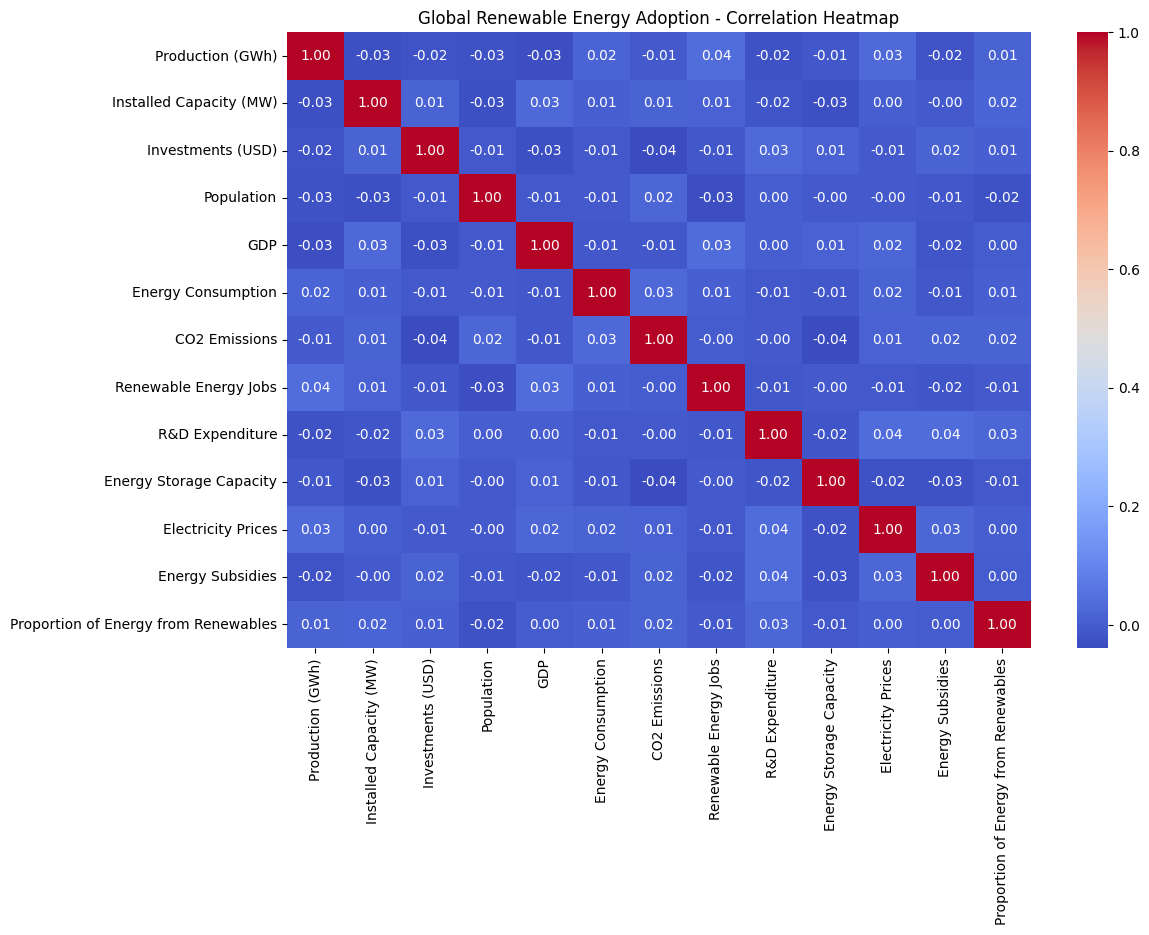

In [5]:
# 4. CORRELATION HEATMAP

plt.figure(figsize=(12, 8))

corr = df[
    [
        "Production (GWh)",
        "Installed Capacity (MW)",
        "Investments (USD)",
        "Population",
        "GDP",
        "Energy Consumption",
        "CO2 Emissions",
        "Renewable Energy Jobs",
        "R&D Expenditure",
        "Energy Storage Capacity",
        "Electricity Prices",
        "Energy Subsidies",
        "Proportion of Energy from Renewables"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Global Renewable Energy Adoption - Correlation Heatmap")

plt.show()

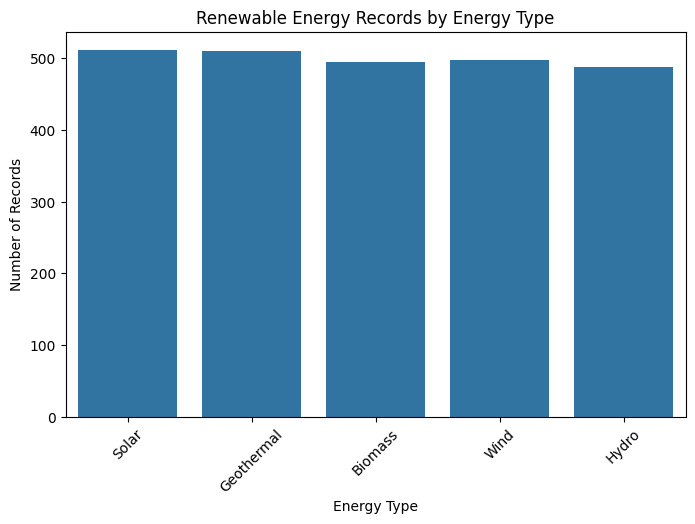

In [6]:
# 5. ENERGY TYPE DISTRIBUTION

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Energy Type"
)

plt.xticks(rotation=45)

plt.title("Renewable Energy Records by Energy Type")
plt.xlabel("Energy Type")
plt.ylabel("Number of Records")

plt.show()

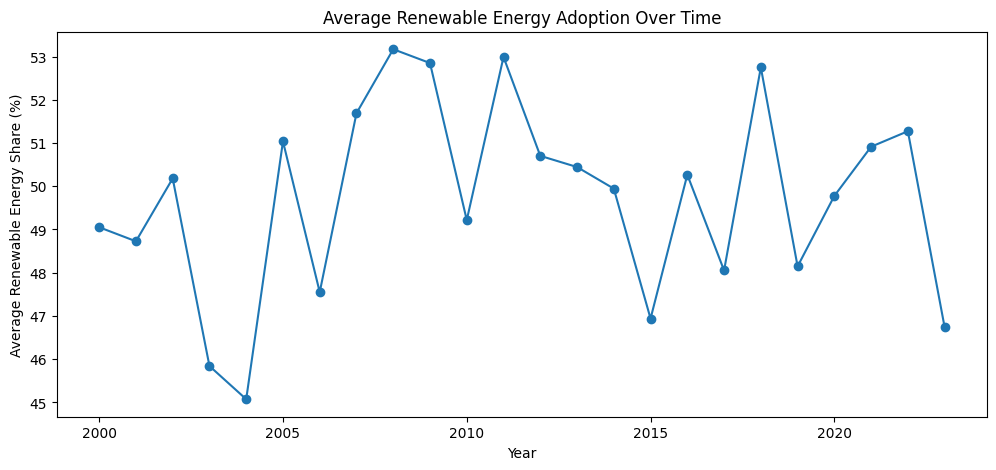

In [7]:
# 6. RENEWABLE ENERGY ADOPTION OVER TIME

df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

yearly = (
    df.groupby("Year")
    ["Proportion of Energy from Renewables"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o"
)

plt.title("Average Renewable Energy Adoption Over Time")
plt.xlabel("Year")
plt.ylabel("Average Renewable Energy Share (%)")

plt.show()

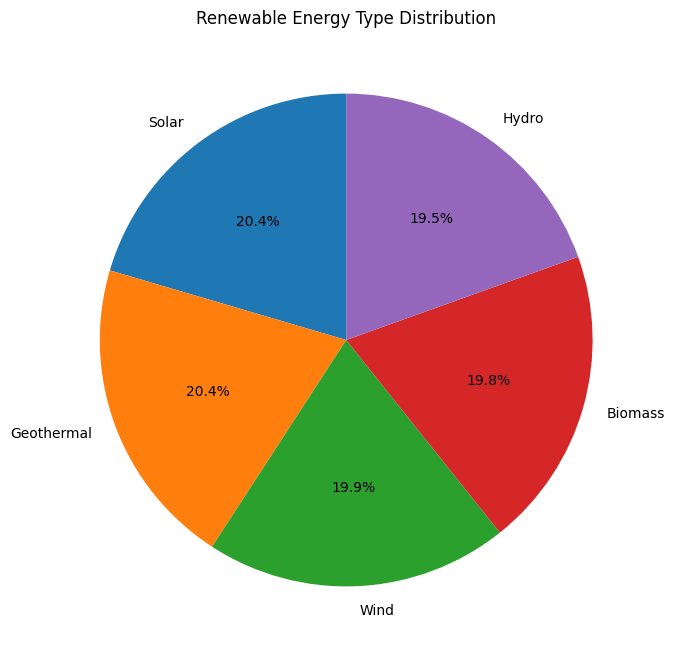

In [8]:
# 7. ENERGY TYPE DISTRIBUTION

energy_type = df["Energy Type"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    energy_type,
    labels=energy_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Renewable Energy Type Distribution")

plt.show()

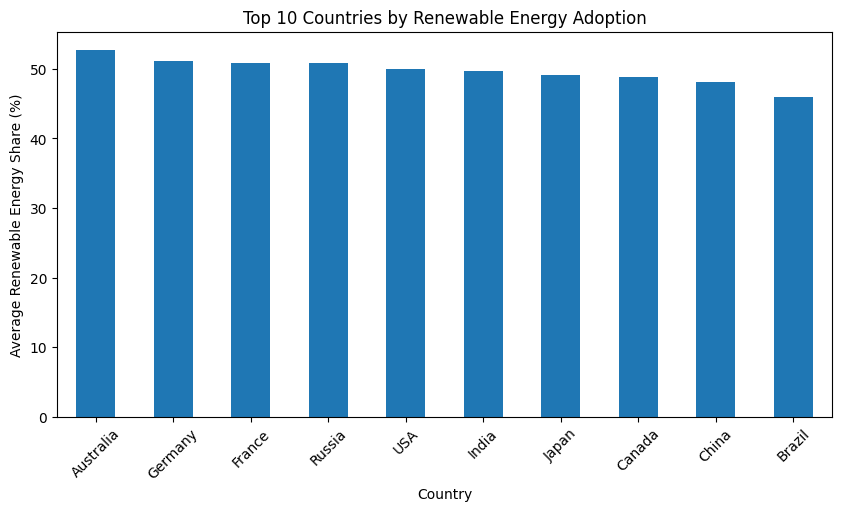

In [9]:
# 8. TOP 10 COUNTRIES BY RENEWABLE ENERGY ADOPTION

country = (
    df.groupby("Country")
    ["Proportion of Energy from Renewables"]
    .mean()
)

country = country.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

country.plot(kind="bar")

plt.title("Top 10 Countries by Renewable Energy Adoption")
plt.xlabel("Country")
plt.ylabel("Average Renewable Energy Share (%)")

plt.xticks(rotation=45)

plt.show()

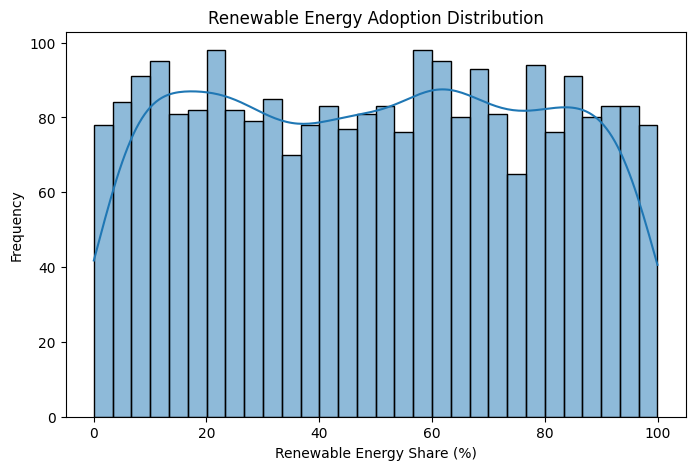

In [10]:
# 9. RENEWABLE ENERGY ADOPTION DISTRIBUTION

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Proportion of Energy from Renewables"],
    bins=30,
    kde=True
)

plt.title("Renewable Energy Adoption Distribution")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Frequency")

plt.show()

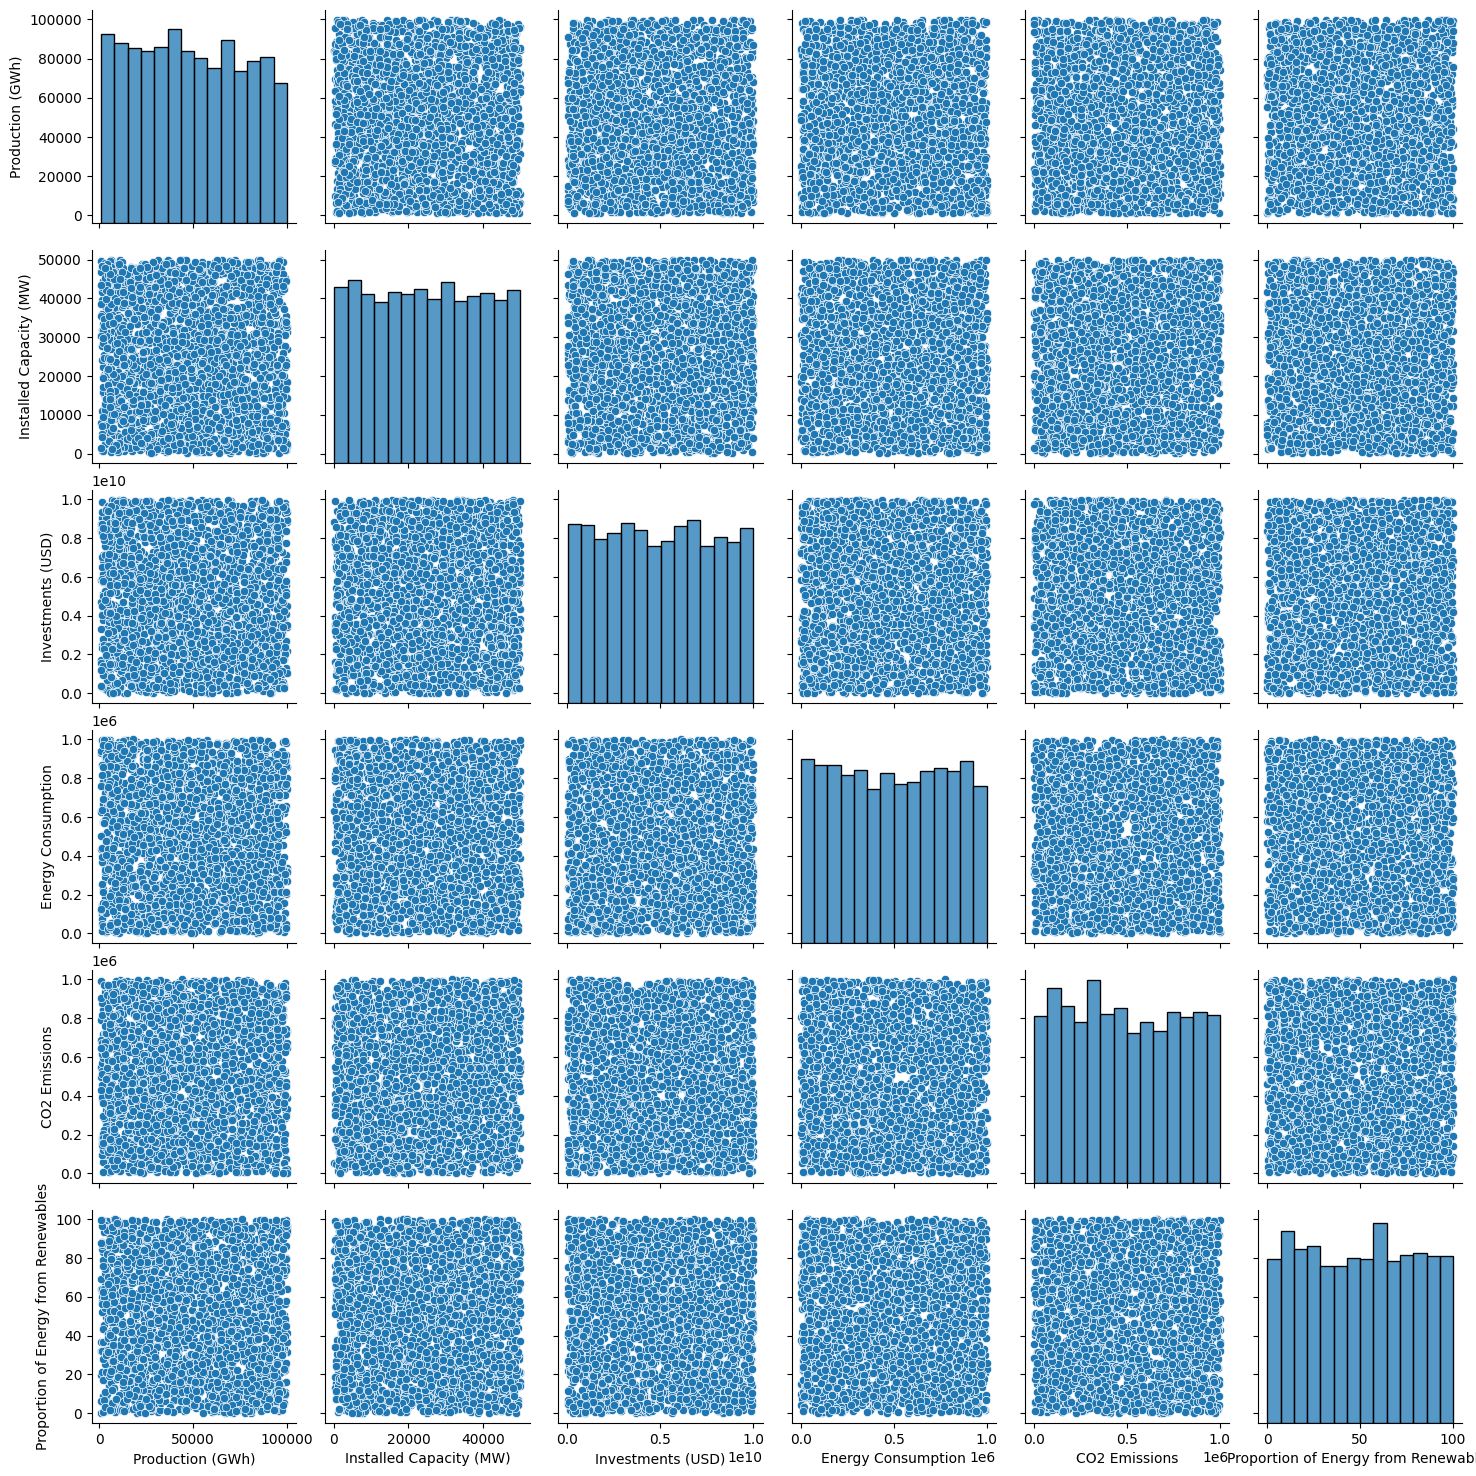

In [11]:
# 10. PAIRPLOT OF MAJOR RENEWABLE ENERGY FACTORS

sns.pairplot(
    df[
        [
            "Production (GWh)",
            "Installed Capacity (MW)",
            "Investments (USD)",
            "Energy Consumption",
            "CO2 Emissions",
            "Proportion of Energy from Renewables"
        ]
    ]
)

plt.show()

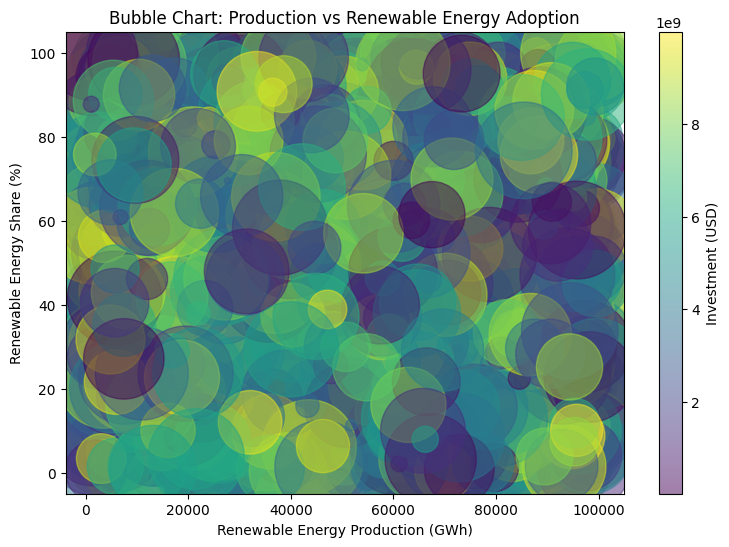

In [12]:
# 11. BUBBLE CHART - PRODUCTION VS ADOPTION

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Production (GWh)"],
    df["Proportion of Energy from Renewables"],
    s=df["Installed Capacity (MW)"] / 10,
    alpha=0.5,
    c=df["Investments (USD)"],
    cmap="viridis"
)

plt.colorbar(
    label="Investment (USD)"
)

plt.xlabel("Renewable Energy Production (GWh)")
plt.ylabel("Renewable Energy Share (%)")

plt.title(
    "Bubble Chart: Production vs Renewable Energy Adoption"
)

plt.show()

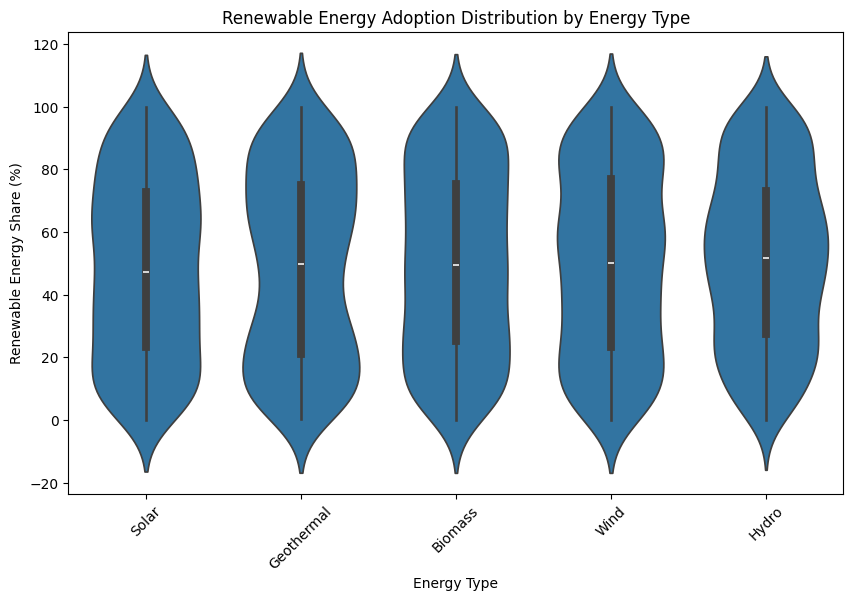

In [13]:
# 12. RENEWABLE ENERGY ADOPTION BY ENERGY TYPE

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Energy Type",
    y="Proportion of Energy from Renewables"
)

plt.xticks(rotation=45)

plt.title("Renewable Energy Adoption Distribution by Energy Type")
plt.xlabel("Energy Type")
plt.ylabel("Renewable Energy Share (%)")

plt.show()

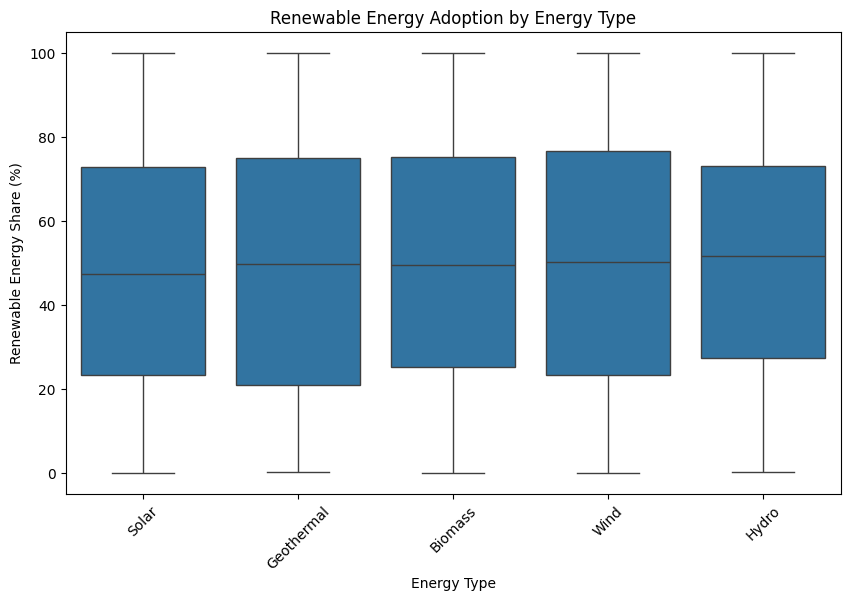

In [14]:
# 13. RENEWABLE ENERGY ADOPTION BY ENERGY TYPE - BOXPLOT

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Energy Type",
    y="Proportion of Energy from Renewables"
)

plt.xticks(rotation=45)

plt.title("Renewable Energy Adoption by Energy Type")
plt.xlabel("Energy Type")
plt.ylabel("Renewable Energy Share (%)")

plt.show()

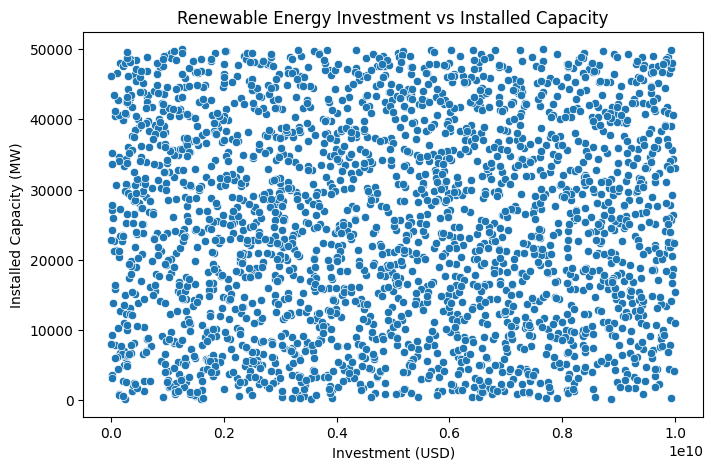

In [15]:
# 14. INVESTMENT VS INSTALLED CAPACITY

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Investments (USD)",
    y="Installed Capacity (MW)"
)

plt.title("Renewable Energy Investment vs Installed Capacity")
plt.xlabel("Investment (USD)")
plt.ylabel("Installed Capacity (MW)")

plt.show()

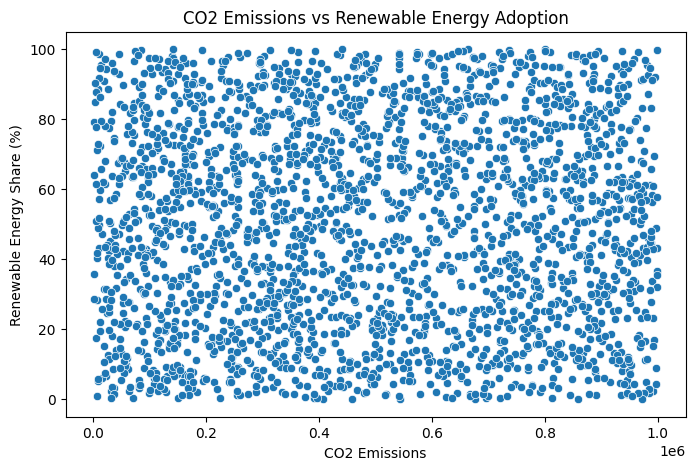

In [16]:
# 15. CO2 EMISSIONS VS RENEWABLE ENERGY ADOPTION

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="CO2 Emissions",
    y="Proportion of Energy from Renewables"
)

plt.title("CO2 Emissions vs Renewable Energy Adoption")
plt.xlabel("CO2 Emissions")
plt.ylabel("Renewable Energy Share (%)")

plt.show()